In [1]:
!pip install biopython pandas numpy scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 10.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from Bio.SeqUtils.ProtParam import ProteinAnalysis

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import requests

url = "https://rest.uniprot.org/uniprotkb/search"

params = {
    "query": "(reviewed:true) AND (length:[100 TO 500])",
    "format": "tsv",
    "fields": "accession,protein_name,sequence,length",
    "size": 100
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

Status code: 200


In [4]:
print(response.text[:1000])

Entry	Protein names	Sequence	Length
A0PK11	Clarin-2	MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDLVNATDRELVKFIGDIYYGLFRGCKVRQCGLGGRQSQFTIFPHLVKELNAGLHVMILLLLFLALALALVSMGFAILNMIQVPYRAVSGPGGICLWNVLAGGVVALAIASFVAAVKFHDLTERIANFQEKLFQFVVVEEQYEESFWICVASASAHAANLVVVAISQIPLPEIKTKIEEATVTAEDILY	232
A1A519	Protein FAM170A (Zinc finger domain-containing protein) (Zinc finger protein ZNFD)	MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQGVGEVTSTSEYCSCVSSSRKLIHSGIQRIHRDSPQPQSPLAQVQERGETPPRSQHVSLSSYSSYKTCVSSLCVNKEERGMKIYYMQVQMNKGVAVSWETEETLESLEKQPRMEEVTLSEVVRVGTPPSDVSTRNLLSDSEPSGEEKEHEERTESDSLPGSPTVEDTPRAKTPDWLVTMENGFRCMACCRVFTTMEALQEHVQFGIREGFSCHVFHLTMAQLTGNMESESTQDEQEEENGNEKEEEEKPEAKEEEGQPTEEDLGLRRSWSQCPGCVFHSPKDRNS	330
A1L3X0	Very long chain fatty acid elongase 7 (EC 2.3.1.199) (3-keto acyl-CoA synthase ELOVL7) (ELOVL fatty acid elongase 7) (ELOVL FA elongase 7) (Elongation of very long chain fatty acids protein 7) (Very long chain 3-ketoacyl-CoA synthase 7) (Very long chain 3-oxoacyl-CoA synthase 7)

In [5]:
from io import StringIO

df = pd.read_csv(StringIO(response.text), sep="\t")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100, 4)


,Entry,Protein names,Sequence,Length
0,A0PK11,Clarin-2,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,232
1,A1A519,Protein FAM170A (Zinc finger domain-containing...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,330
2,A1L3X0,Very long chain fatty acid elongase 7 (EC 2.3....,MAFSDLTSRTVHLYDNWIKDADPRVEDWLLMSSPLPQTILLGFYVY...,281
3,A2RU14,Transmembrane protein 218,MAGTVLGVGAGVFILALLWVAVLLLCVLLSRASGAARFSVIFLFFG...,115
4,A2RUC4,tRNA wybutosine-synthesizing protein 5 (hTYW5)...,MAGQHLPVPRLEGVSREQFMQHLYPQRKPLVLEGIDLGPCTSKWTV...,315


In [6]:
print("Number of proteins:", len(df))
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate entries:", df["Entry"].duplicated().sum())

print("\nSequence lengths:")
print(df["Length"].describe())

Number of proteins: 100

Missing values:
Entry            0
Protein names    0
Sequence         0
Length           0
dtype: int64

Duplicate entries: 0

Sequence lengths:
count    100.000000
mean     302.270000
std      111.591775
min      114.000000
25%      210.750000
50%      308.500000
75%      399.500000
max      492.000000
Name: Length, dtype: float64


In [1]:
valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

def check_sequence(sequence):
    return set(sequence).issubset(valid_amino_acids)

df["Valid_Sequence"] = df["Sequence"].apply(check_sequence)

print("Valid sequences:", df["Valid_Sequence"].sum())
print("Invalid sequences:", (~df["Valid_Sequence"]).sum())

NameError: name 'df' is not defined

In [2]:
from io import StringIO
import pandas as pd

df = pd.read_csv(StringIO(response.text), sep="\t")

print("Dataset shape:", df.shape)
df.head()

NameError: name 'response' is not defined

In [3]:
import requests

url = "https://rest.uniprot.org/uniprotkb/search"

params = {
    "query": "(reviewed:true) AND (length:[100 TO 500])",
    "format": "tsv",
    "fields": "accession,protein_name,sequence,length",
    "size": 100
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

Status code: 200


In [4]:
from io import StringIO
import pandas as pd

df = pd.read_csv(StringIO(response.text), sep="\t")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100, 4)


,Entry,Protein names,Sequence,Length
0,A0PK11,Clarin-2,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,232
1,A1A519,Protein FAM170A (Zinc finger domain-containing...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,330
2,A1L3X0,Very long chain fatty acid elongase 7 (EC 2.3....,MAFSDLTSRTVHLYDNWIKDADPRVEDWLLMSSPLPQTILLGFYVY...,281
3,A2RU14,Transmembrane protein 218,MAGTVLGVGAGVFILALLWVAVLLLCVLLSRASGAARFSVIFLFFG...,115
4,A2RUC4,tRNA wybutosine-synthesizing protein 5 (hTYW5)...,MAGQHLPVPRLEGVSREQFMQHLYPQRKPLVLEGIDLGPCTSKWTV...,315


In [5]:
valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

def check_sequence(sequence):
    return set(sequence).issubset(valid_amino_acids)

df["Valid_Sequence"] = df["Sequence"].apply(check_sequence)

print("Valid sequences:", df["Valid_Sequence"].sum())
print("Invalid sequences:", (~df["Valid_Sequence"]).sum())

Valid sequences: 100
Invalid sequences: 0


In [6]:
import requests
import pandas as pd
from io import StringIO

classes = {
    "EC1": "Oxidoreductases",
    "EC2": "Transferases",
    "EC3": "Hydrolases",
    "EC4": "Lyases"
}

all_data = []

for ec_class, class_name in classes.items():

    ec_number = ec_class[-1]

    query = f"(reviewed:true) AND (ec:{ec_number}*) AND (length:[100 TO 500])"

    url = "https://rest.uniprot.org/uniprotkb/search"

    params = {
        "query": query,
        "format": "tsv",
        "fields": "accession,protein_name,sequence,length,ec",
        "size": 50
    }

    response = requests.get(url, params=params)

    print(ec_class, class_name, "Status:", response.status_code)

    temp_df = pd.read_csv(StringIO(response.text), sep="\t")

    temp_df["Function_Class"] = class_name
    temp_df["EC_Class"] = ec_class

    all_data.append(temp_df)

df = pd.concat(all_data, ignore_index=True)

print("\nFinal dataset shape:", df.shape)
print("\nClass distribution:")
print(df["Function_Class"].value_counts())

df.head()

EC1 Oxidoreductases Status: 200
EC2 Transferases Status: 200
EC3 Hydrolases Status: 200
EC4 Lyases Status: 200

Final dataset shape: (200, 7)

Class distribution:
Function_Class
Oxidoreductases    50
Transferases       50
Hydrolases         50
Lyases             50
Name: count, dtype: int64


,Entry,Protein names,Sequence,Length,EC number,Function_Class,EC_Class
0,A2RUC4,tRNA wybutosine-synthesizing protein 5 (hTYW5)...,MAGQHLPVPRLEGVSREQFMQHLYPQRKPLVLEGIDLGPCTSKWTV...,315,1.14.11.42,Oxidoreductases,EC1
1,A5PLL7,Plasmanylethanolamine desaturase 1 (EC 1.14.19...,MAGAENWPGQQLELDEDEASCCRWGAQHAGARELAALYSPGKRLQE...,270,1.14.19.77,Oxidoreductases,EC1
2,C9JRZ8,Aldo-keto reductase family 1 member B15 (EC 1....,MATFVELSTKAKMPIVGLGTWRSLLGKVKEAVKVAIDAEYRHIDCA...,316,1.1.1.-; 1.1.1.216; 1.1.1.300; 1.1.1.54; 1.1.1.64,Oxidoreductases,EC1
3,O14756,17-beta-hydroxysteroid dehydrogenase type 6 (1...,MWLYLAAFVGLYYLLHWYRERQVVSHLQDKYVFITGCDSGFGNLLA...,317,1.1.1.105; 1.1.1.209; 1.1.1.239; 1.1.1.53; 1.1...,Oxidoreductases,EC1
4,O15247,Chloride intracellular channel protein 2 (Glut...,MSGLRPGTQVDPEIELFVKAGSDGESIGNCPFCQRLFMILWLKGVK...,247,1.11.1.-; 1.8.-.-,Oxidoreductases,EC1


In [7]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate UniProt entries:", df["Entry"].duplicated().sum())

print("\nDuplicate sequences:", df["Sequence"].duplicated().sum())

print("\nSequence length statistics:")
print(df["Length"].describe())

Dataset shape: (200, 7)

Missing values:
Entry             0
Protein names     0
Sequence          0
Length            0
EC number         0
Function_Class    0
EC_Class          0
dtype: int64

Duplicate UniProt entries: 7

Duplicate sequences: 7

Sequence length statistics:
count    200.000000
mean     336.870000
std       98.484206
min      145.000000
25%      264.000000
50%      335.500000
75%      421.000000
max      500.000000
Name: Length, dtype: float64


In [8]:
print("Before removing duplicates:", len(df))

df = df.drop_duplicates(subset="Entry").reset_index(drop=True)

print("After removing duplicates:", len(df))

print("\nClass distribution after removing duplicates:")
print(df["Function_Class"].value_counts())

Before removing duplicates: 200
After removing duplicates: 193

Class distribution after removing duplicates:
Function_Class
Oxidoreductases    50
Lyases             49
Transferases       47
Hydrolases         47
Name: count, dtype: int64


In [9]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

def amino_acid_composition(sequence):
    analysis = ProteinAnalysis(sequence)

    return {
        aa: analysis.get_amino_acids_percent()[aa]
        for aa in amino_acids
    }

aa_features = df["Sequence"].apply(amino_acid_composition)

aa_features_df = pd.DataFrame(aa_features.tolist())

print("Feature matrix shape:", aa_features_df.shape)

aa_features_df.head()

ModuleNotFoundError: No module named 'Bio'

In [10]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.6 MB/s eta 0:00:00


In [11]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import pandas as pd

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

def amino_acid_composition(sequence):
    analysis = ProteinAnalysis(sequence)

    return {
        aa: analysis.get_amino_acids_percent()[aa]
        for aa in amino_acids
    }

aa_features = df["Sequence"].apply(amino_acid_composition)

aa_features_df = pd.DataFrame(aa_features.tolist())

print("Feature matrix shape:", aa_features_df.shape)

aa_features_df.head()

AttributeError: 'ProteinAnalysis' object has no attribute 'get_amino_acids_percent'

In [12]:
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

def amino_acid_composition(sequence):
    sequence_length = len(sequence)

    return {
        aa: sequence.count(aa) / sequence_length
        for aa in amino_acids
    }

aa_features = df["Sequence"].apply(amino_acid_composition)

aa_features_df = pd.DataFrame(aa_features.tolist())

print("Feature matrix shape:", aa_features_df.shape)

aa_features_df.head()

Feature matrix shape: (193, 20)


,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
0,0.063492,0.009524,0.066667,0.073016,0.063492,0.047619,0.025397,0.041270,0.082540,0.101587,0.015873,0.025397,0.053968,0.047619,0.057143,0.060317,0.031746,0.073016,0.012698,0.047619
1,0.074074,0.029630,0.044444,0.062963,0.048148,0.066667,0.059259,0.066667,0.037037,0.129630,0.011111,0.025926,0.051852,0.033333,0.051852,0.033333,0.055556,0.048148,0.048148,0.022222
2,0.066456,0.009494,0.060127,0.085443,0.066456,0.044304,0.031646,0.060127,0.098101,0.085443,0.022152,0.031646,0.053797,0.034810,0.034810,0.044304,0.050633,0.069620,0.018987,0.031646
3,0.069401,0.018927,0.037855,0.050473,0.037855,0.072555,0.022082,0.050473,0.044164,0.119874,0.031546,0.037855,0.028391,0.041009,0.063091,0.059937,0.066246,0.078864,0.025237,0.044164
4,0.060729,0.020243,0.068826,0.089069,0.064777,0.040486,0.012146,0.044534,0.097166,0.109312,0.012146,0.052632,0.072874,0.024291,0.040486,0.048583,0.052632,0.044534,0.008097,0.036437


In [13]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def physicochemical_features(sequence):
    analysis = ProteinAnalysis(sequence)

    return {
        "Molecular_Weight": analysis.molecular_weight(),
        "Aromaticity": analysis.aromaticity(),
        "Instability_Index": analysis.instability_index(),
        "Isoelectric_Point": analysis.isoelectric_point(),
        "GRAVY": analysis.gravy()
    }

physico_features = df["Sequence"].apply(physicochemical_features)

physico_features_df = pd.DataFrame(physico_features.tolist())

print("Physicochemical feature matrix shape:", physico_features_df.shape)

physico_features_df.head()

KeyError: 'U'

In [14]:
unusual_residues = df["Sequence"].apply(
    lambda seq: sorted(set(seq) - set("ACDEFGHIKLMNPQRSTVWY"))
)

problematic = df[unusual_residues.apply(len) > 0][
    ["Entry", "Protein names", "Sequence"]
].copy()

print("Proteins with non-standard residues:", len(problematic))

for _, row in problematic.iterrows():
    residues = sorted(set(row["Sequence"]) - set("ACDEFGHIKLMNPQRSTVWY"))
    print("\nEntry:", row["Entry"])
    print("Unusual residue(s):", residues)

Proteins with non-standard residues: 1

Entry: P49895
Unusual residue(s): ['U']


In [15]:
print("Proteins before removal:", len(df))

df = df[df["Entry"] != "P49895"].reset_index(drop=True)

print("Proteins after removal:", len(df))

print("\nUpdated class distribution:")
print(df["Function_Class"].value_counts())

Proteins before removal: 193
Proteins after removal: 192

Updated class distribution:
Function_Class
Oxidoreductases    49
Lyases             49
Transferases       47
Hydrolases         47
Name: count, dtype: int64


In [16]:
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

def amino_acid_composition(sequence):
    sequence_length = len(sequence)

    return {
        aa: sequence.count(aa) / sequence_length
        for aa in amino_acids
    }

aa_features = df["Sequence"].apply(amino_acid_composition)

aa_features_df = pd.DataFrame(aa_features.tolist())

print("Amino-acid feature matrix shape:", aa_features_df.shape)

Amino-acid feature matrix shape: (192, 20)


In [17]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def physicochemical_features(sequence):
    analysis = ProteinAnalysis(sequence)

    return {
        "Molecular_Weight": analysis.molecular_weight(),
        "Aromaticity": analysis.aromaticity(),
        "Instability_Index": analysis.instability_index(),
        "Isoelectric_Point": analysis.isoelectric_point(),
        "GRAVY": analysis.gravy()
    }

physico_features = df["Sequence"].apply(physicochemical_features)

physico_features_df = pd.DataFrame(physico_features.tolist())

print("Physicochemical feature matrix shape:", physico_features_df.shape)

physico_features_df.head()

Physicochemical feature matrix shape: (192, 5)


,Molecular_Weight,Aromaticity,Instability_Index,Isoelectric_Point,GRAVY
0,36547.3892,0.123810,48.391778,7.096371,-0.429524
1,31134.5974,0.118519,37.964444,6.333251,-0.040000
2,36536.6087,0.117089,28.892753,6.231395,-0.356329
3,35965.2737,0.107256,30.485489,8.935850,-0.008833
4,28356.0533,0.109312,43.945344,5.442811,-0.517814


In [18]:
# Combine amino-acid composition and physicochemical features
X = pd.concat(
    [aa_features_df, physico_features_df],
    axis=1
)

# Target variable
y = df["Function_Class"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.value_counts())

Feature matrix shape: (192, 25)
Target shape: (192,)

Feature names:
['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y', 'Molecular_Weight', 'Aromaticity', 'Instability_Index', 'Isoelectric_Point', 'GRAVY']

Target classes:
Function_Class
Oxidoreductases    49
Lyases             49
Transferases       47
Hydrolases         47
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (153, 25)
Testing set: (39, 25)

Training class distribution:
Function_Class
Oxidoreductases    39
Lyases             39
Transferases       38
Hydrolases         37
Name: count, dtype: int64

Testing class distribution:
Function_Class
Oxidoreductases    10
Lyases             10
Hydrolases         10
Transferases        9
Name: count, dtype: int64


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(accuracy_lr, 4))

Logistic Regression Accuracy: 0.3846


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(accuracy_rf, 4))

Random Forest Accuracy: 0.2564


In [22]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", round(accuracy_svm, 4))

SVM Accuracy: 0.3846


In [23]:
from sklearn.metrics import classification_report

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_test, y_pred_lr))

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print(classification_report(y_test, y_pred_rf))

print("=" * 60)
print("SVM")
print("=" * 60)
print(classification_report(y_test, y_pred_svm))

LOGISTIC REGRESSION
                 precision    recall  f1-score   support

     Hydrolases       0.40      0.40      0.40        10
         Lyases       0.60      0.30      0.40        10
Oxidoreductases       0.29      0.50      0.37        10
   Transferases       0.43      0.33      0.38         9

       accuracy                           0.38        39
      macro avg       0.43      0.38      0.39        39
   weighted avg       0.43      0.38      0.39        39

RANDOM FOREST
                 precision    recall  f1-score   support

     Hydrolases       0.29      0.20      0.24        10
         Lyases       0.43      0.30      0.35        10
Oxidoreductases       0.18      0.30      0.22        10
   Transferases       0.25      0.22      0.24         9

       accuracy                           0.26        39
      macro avg       0.29      0.26      0.26        39
   weighted avg       0.29      0.26      0.26        39

SVM
                 precision    recall  f1-sco

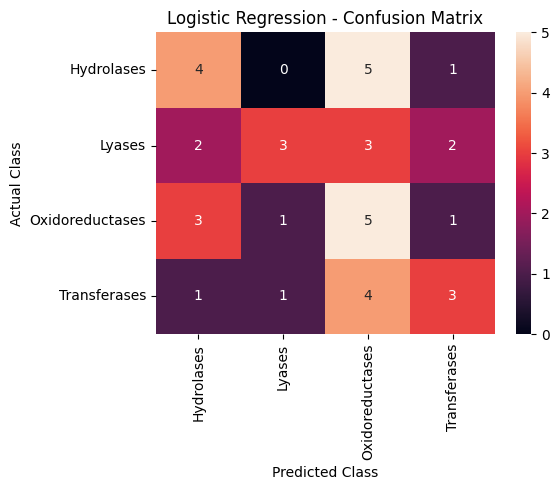

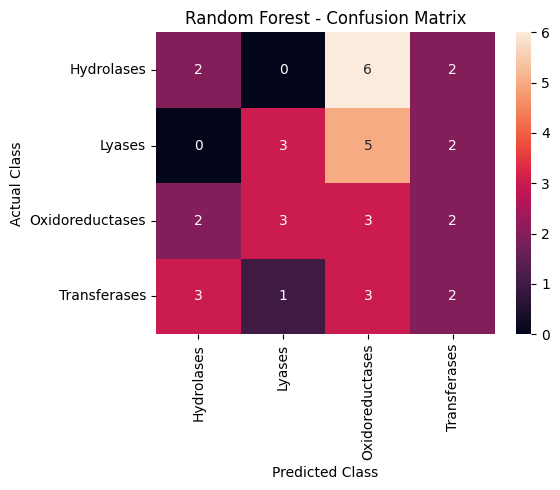

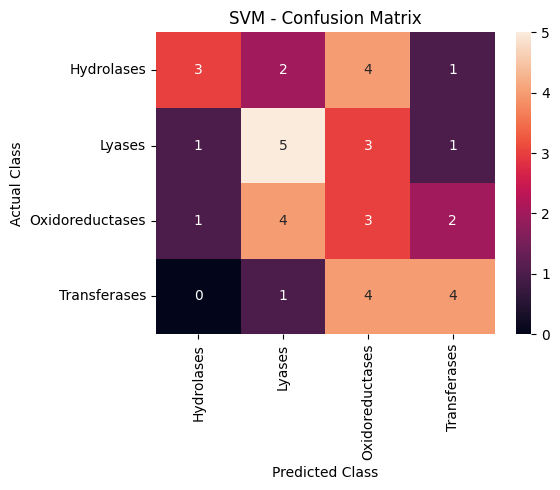

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

class_names = [
    "Hydrolases",
    "Lyases",
    "Oxidoreductases",
    "Transferases"
]

for model_name, predictions in models.items():

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=class_names
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

In [25]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

              Feature  Importance
17                  V    0.059175
2                   D    0.052910
5                   G    0.052203
22  Instability_Index    0.049081
23  Isoelectric_Point    0.043845
16                  T    0.043102
0                   A    0.041720
24              GRAVY    0.041148
9                   L    0.040273
15                  S    0.039844


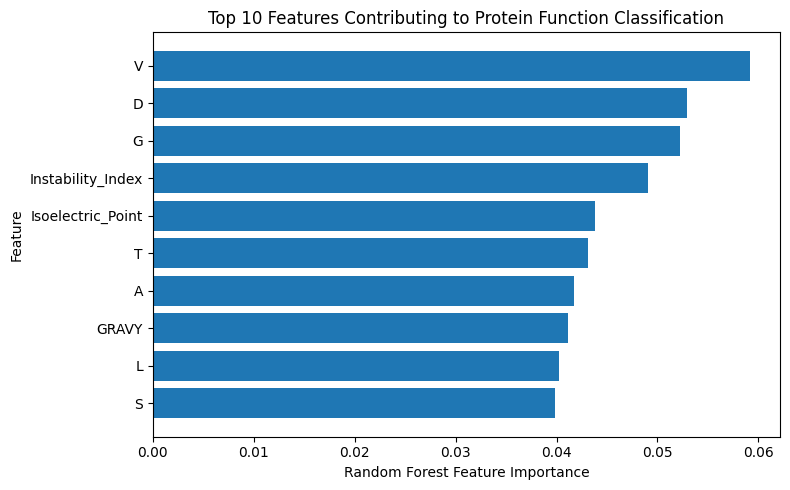

In [26]:
top_features = feature_importance.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Contributing to Protein Function Classification")

plt.tight_layout()
plt.show()

In [27]:
# Select one protein from the test set

example_index = X_test.index[0]

example_sequence = df.loc[example_index, "Sequence"]
actual_class = df.loc[example_index, "Function_Class"]
protein_name = df.loc[example_index, "Protein names"]

print("Protein:", protein_name)
print("Sequence length:", len(example_sequence))
print("Actual class:", actual_class)

# Create features for the example protein
example_aa = amino_acid_composition(example_sequence)
example_physico = physicochemical_features(example_sequence)

example_features = pd.DataFrame(
    [{**example_aa, **example_physico}]
)

# Make predictions
prediction_lr = logistic_model.predict(example_features)[0]
prediction_rf = rf_model.predict(example_features)[0]
prediction_svm = svm_model.predict(example_features)[0]

print("\nPredictions:")
print("Logistic Regression:", prediction_lr)
print("Random Forest:", prediction_rf)
print("SVM:", prediction_svm)

Protein: Persulfide dioxygenase ETHE1, mitochondrial (EC 1.13.11.18) (Ethylmalonic encephalopathy protein 1) (Hepatoma subtracted clone one protein) (Sulfur dioxygenase ETHE1)
Sequence length: 254
Actual class: Oxidoreductases

Predictions:
Logistic Regression: Hydrolases
Random Forest: Oxidoreductases
SVM: Lyases


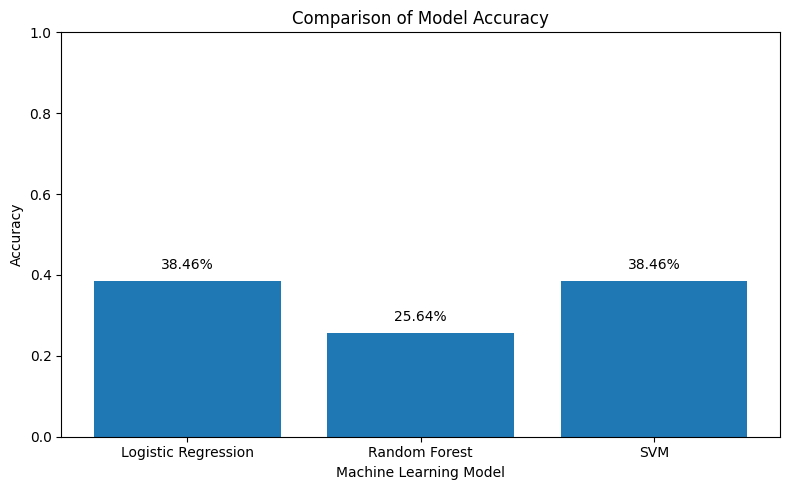

In [28]:
# Compare model accuracy

model_names = [
    "Logistic Regression",
    "Random Forest",
    "SVM"
]

accuracies = [
    accuracy_lr,
    accuracy_rf,
    accuracy_svm
]

plt.figure(figsize=(8, 5))

plt.bar(model_names, accuracies)

plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Model")
plt.title("Comparison of Model Accuracy")

plt.ylim(0, 1)

for i, accuracy in enumerate(accuracies):
    plt.text(
        i,
        accuracy + 0.03,
        f"{accuracy:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [29]:
# Create a model performance summary

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_svm
    ]
})

results["Accuracy_Percentage"] = results["Accuracy"] * 100

results

,Model,Accuracy,Accuracy_Percentage
0,Logistic Regression,0.384615,38.461538
1,Random Forest,0.256410,25.641026
2,SVM,0.384615,38.461538


In [30]:
results.to_csv("model_performance.csv", index=False)

print("Saved: model_performance.csv")

Saved: model_performance.csv


In [31]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Saved: feature_importance.csv")

Saved: feature_importance.csv


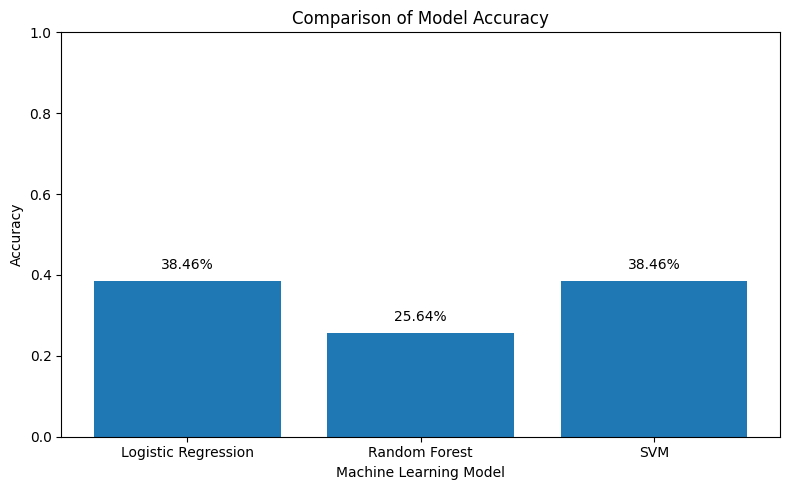

Saved: model_accuracy_comparison.png


In [32]:
# Save model accuracy comparison figure

plt.figure(figsize=(8, 5))

plt.bar(model_names, accuracies)

plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Model")
plt.title("Comparison of Model Accuracy")

plt.ylim(0, 1)

for i, accuracy in enumerate(accuracies):
    plt.text(
        i,
        accuracy + 0.03,
        f"{accuracy:.2%}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: model_accuracy_comparison.png")

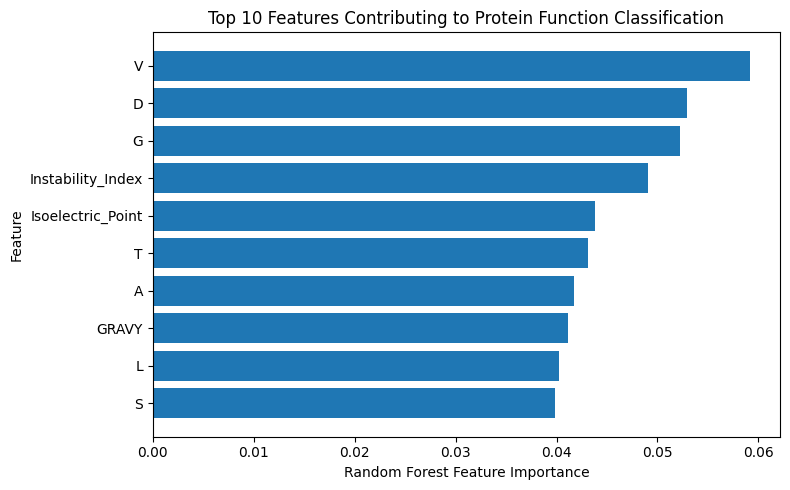

Saved: top_10_feature_importance.png


In [33]:
# Save top 10 feature importance figure

top_features = feature_importance.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Contributing to Protein Function Classification")

plt.tight_layout()

plt.savefig(
    "top_10_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: top_10_feature_importance.png")

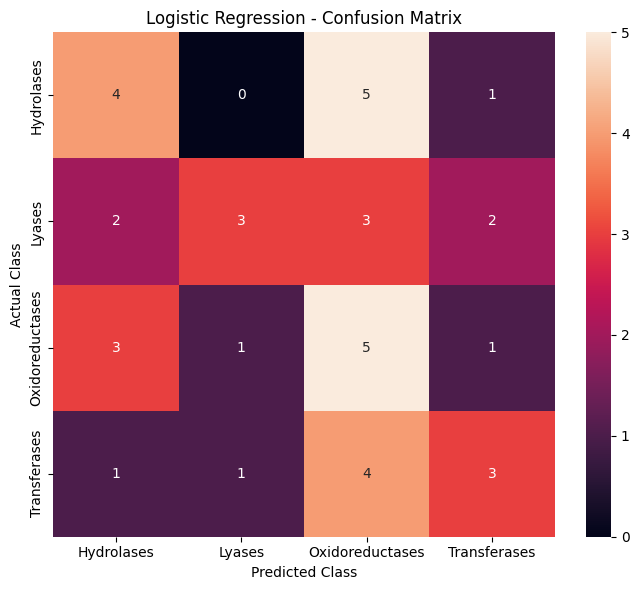

Saved: logistic_regression_confusion_matrix.png


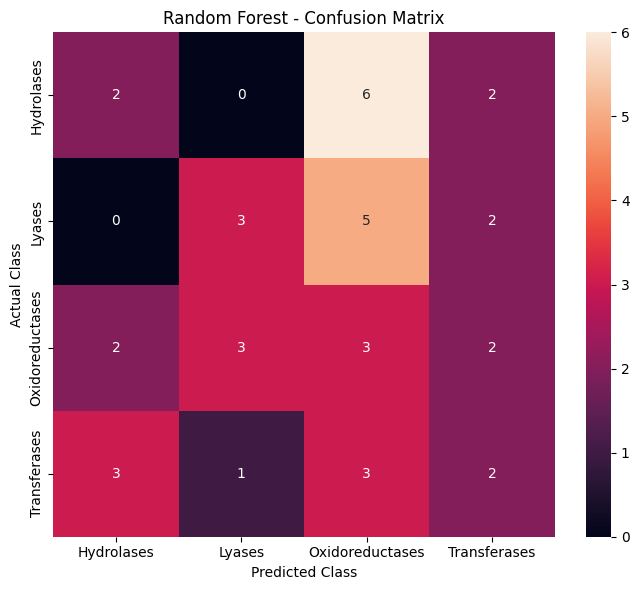

Saved: random_forest_confusion_matrix.png


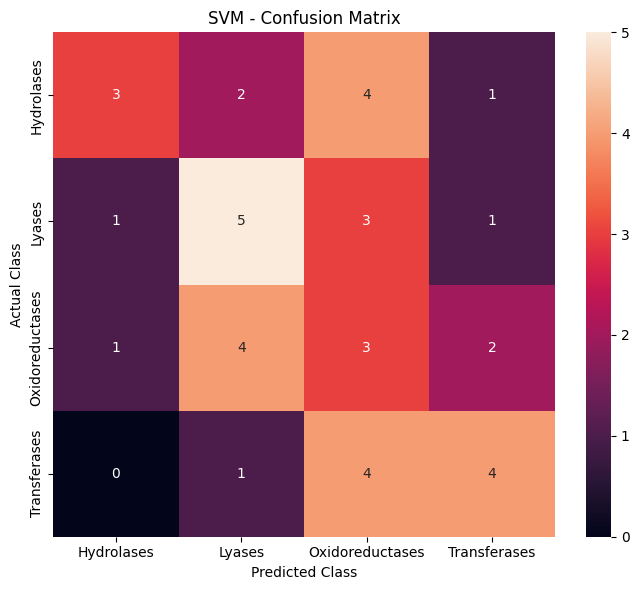

Saved: svm_confusion_matrix.png


In [34]:
# Save confusion matrices for all three models

confusion_data = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

for model_name, predictions in confusion_data.items():

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=class_names
    )

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()

    filename = (
        model_name.lower()
        .replace(" ", "_")
        + "_confusion_matrix.png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {filename}")

In [35]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for all three models

cv_lr = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

cv_rf = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

cv_svm = cross_val_score(
    svm_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression:")
print(cv_lr)
print("Mean Accuracy:", cv_lr.mean())

print("\nRandom Forest:")
print(cv_rf)
print("Mean Accuracy:", cv_rf.mean())

print("\nSVM:")
print(cv_svm)
print("Mean Accuracy:", cv_svm.mean())

Logistic Regression:
[0.28205128 0.41025641 0.21052632 0.28947368 0.36842105]
Mean Accuracy: 0.31214574898785424

Random Forest:
[0.30769231 0.38461538 0.31578947 0.34210526 0.31578947]
Mean Accuracy: 0.3331983805668016

SVM:
[0.23076923 0.30769231 0.23684211 0.28947368 0.44736842]
Mean Accuracy: 0.3024291497975709


In [36]:
from itertools import product

# Generate all possible amino-acid pairs
dipeptides = [
    aa1 + aa2
    for aa1, aa2 in product(amino_acids, repeat=2)
]

print("Number of possible dipeptides:", len(dipeptides))
print("First 20 dipeptides:", dipeptides[:20])

Number of possible dipeptides: 400
First 20 dipeptides: ['AA', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AI', 'AK', 'AL', 'AM', 'AN', 'AP', 'AQ', 'AR', 'AS', 'AT', 'AV', 'AW', 'AY']


In [37]:
def dipeptide_composition(sequence):
    sequence_length = len(sequence)

    # Count consecutive amino-acid pairs
    counts = {
        dp: 0
        for dp in dipeptides
    }

    for i in range(sequence_length - 1):
        dp = sequence[i:i+2]
        if dp in counts:
            counts[dp] += 1

    # Convert counts into frequencies
    total_dipeptides = sequence_length - 1

    return {
        dp: counts[dp] / total_dipeptides
        for dp in dipeptides
    }


# Calculate dipeptide features for all proteins
dipeptide_features = df["Sequence"].apply(dipeptide_composition)

# Convert into a DataFrame
dipeptide_features_df = pd.DataFrame(dipeptide_features.tolist())

print("Dipeptide feature shape:", dipeptide_features_df.shape)
print("\nFirst 5 dipeptide features:")
print(dipeptide_features_df.iloc[:5, :10])

Dipeptide feature shape: (192, 400)

First 5 dipeptide features:
         AA        AC        AD        AE        AF        AG        AH  \
0  0.012739  0.000000  0.003185  0.006369  0.000000  0.006369  0.000000   
1  0.003717  0.000000  0.011152  0.003717  0.003717  0.011152  0.003717   
2  0.003175  0.000000  0.000000  0.006349  0.006349  0.000000  0.003175   
3  0.012658  0.003165  0.003165  0.003165  0.009494  0.006329  0.000000   
4  0.004065  0.000000  0.004065  0.008130  0.000000  0.004065  0.000000   

         AI        AK        AL  
0  0.000000  0.003185  0.006369  
1  0.003717  0.000000  0.011152  
2  0.006349  0.009524  0.003175  
3  0.000000  0.003165  0.006329  
4  0.000000  0.012195  0.000000  


In [38]:
# Combine amino-acid, physicochemical, and dipeptide features
X_dipeptide = pd.concat(
    [aa_features_df, physico_features_df, dipeptide_features_df],
    axis=1
)

print("New feature matrix shape:", X_dipeptide.shape)
print("Number of features:", X_dipeptide.shape[1])

New feature matrix shape: (192, 425)
Number of features: 425


In [39]:
# Use the exact same proteins that were used in the original train/test split

X_train_dipeptide = X_dipeptide.loc[X_train.index]
X_test_dipeptide = X_dipeptide.loc[X_test.index]

print("Dipeptide training set:", X_train_dipeptide.shape)
print("Dipeptide testing set:", X_test_dipeptide.shape)

Dipeptide training set: (153, 425)
Dipeptide testing set: (39, 425)


In [40]:
# Logistic Regression using dipeptide features

logistic_dipeptide = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Train the model
logistic_dipeptide.fit(X_train_dipeptide, y_train)

# Predict on the test set
y_pred_lr_dipeptide = logistic_dipeptide.predict(X_test_dipeptide)

# Calculate accuracy
accuracy_lr_dipeptide = accuracy_score(
    y_test,
    y_pred_lr_dipeptide
)

print("Logistic Regression Accuracy with Dipeptides:",
      accuracy_lr_dipeptide)

print("Accuracy (%):",
      round(accuracy_lr_dipeptide * 100, 2))

Logistic Regression Accuracy with Dipeptides: 0.3333333333333333
Accuracy (%): 33.33


In [41]:
# Random Forest using dipeptide features

rf_dipeptide = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# Train the model
rf_dipeptide.fit(X_train_dipeptide, y_train)

# Predict on the test set
y_pred_rf_dipeptide = rf_dipeptide.predict(X_test_dipeptide)

# Calculate accuracy
accuracy_rf_dipeptide = accuracy_score(
    y_test,
    y_pred_rf_dipeptide
)

print("Random Forest Accuracy with Dipeptides:",
      accuracy_rf_dipeptide)

print("Accuracy (%):",
      round(accuracy_rf_dipeptide * 100, 2))

Random Forest Accuracy with Dipeptides: 0.4358974358974359
Accuracy (%): 43.59


In [42]:
# SVM using dipeptide features

svm_dipeptide = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

# Train the model
svm_dipeptide.fit(X_train_dipeptide, y_train)

# Predict on the test set
y_pred_svm_dipeptide = svm_dipeptide.predict(X_test_dipeptide)

# Calculate accuracy
accuracy_svm_dipeptide = accuracy_score(
    y_test,
    y_pred_svm_dipeptide
)

print("SVM Accuracy with Dipeptides:",
      accuracy_svm_dipeptide)

print("Accuracy (%):",
      round(accuracy_svm_dipeptide * 100, 2))

SVM Accuracy with Dipeptides: 0.41025641025641024
Accuracy (%): 41.03


In [43]:
from sklearn.metrics import classification_report

print("===== LOGISTIC REGRESSION =====")
print(classification_report(y_test, y_pred_lr_dipeptide))

print("\n===== RANDOM FOREST =====")
print(classification_report(y_test, y_pred_rf_dipeptide))

print("\n===== SVM =====")
print(classification_report(y_test, y_pred_svm_dipeptide))

===== LOGISTIC REGRESSION =====
                 precision    recall  f1-score   support

     Hydrolases       0.43      0.30      0.35        10
         Lyases       0.29      0.20      0.24        10
Oxidoreductases       0.29      0.40      0.33        10
   Transferases       0.36      0.44      0.40         9

       accuracy                           0.33        39
      macro avg       0.34      0.34      0.33        39
   weighted avg       0.34      0.33      0.33        39


===== RANDOM FOREST =====
                 precision    recall  f1-score   support

     Hydrolases       0.33      0.20      0.25        10
         Lyases       0.62      0.50      0.56        10
Oxidoreductases       0.31      0.40      0.35        10
   Transferases       0.50      0.67      0.57         9

       accuracy                           0.44        39
      macro avg       0.44      0.44      0.43        39
   weighted avg       0.44      0.44      0.43        39


===== SVM =====
      

In [44]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for dipeptide models

cv_lr_dipeptide = cross_val_score(
    logistic_dipeptide,
    X_dipeptide,
    y,
    cv=5,
    scoring="accuracy"
)

cv_rf_dipeptide = cross_val_score(
    rf_dipeptide,
    X_dipeptide,
    y,
    cv=5,
    scoring="accuracy"
)

cv_svm_dipeptide = cross_val_score(
    svm_dipeptide,
    X_dipeptide,
    y,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV scores:", cv_lr_dipeptide)
print("Mean:", cv_lr_dipeptide.mean())

print("\nRandom Forest CV scores:", cv_rf_dipeptide)
print("Mean:", cv_rf_dipeptide.mean())

print("\nSVM CV scores:", cv_svm_dipeptide)
print("Mean:", cv_svm_dipeptide.mean())

Logistic Regression CV scores: [0.30769231 0.41025641 0.36842105 0.23684211 0.47368421]
Mean: 0.3593792172739541

Random Forest CV scores: [0.28205128 0.35897436 0.42105263 0.47368421 0.47368421]
Mean: 0.40188933873144395

SVM CV scores: [0.20512821 0.25641026 0.39473684 0.36842105 0.42105263]
Mean: 0.3291497975708502


In [45]:
import numpy as np

print("===== ORIGINAL FEATURES =====")

print(
    "Logistic Regression:",
    round(cv_lr.mean() * 100, 2), "% ±",
    round(cv_lr.std() * 100, 2), "%"
)

print(
    "Random Forest:",
    round(cv_rf.mean() * 100, 2), "% ±",
    round(cv_rf.std() * 100, 2), "%"
)

print(
    "SVM:",
    round(cv_svm.mean() * 100, 2), "% ±",
    round(cv_svm.std() * 100, 2), "%"
)


print("\n===== DIPEPTIDE FEATURES =====")

print(
    "Logistic Regression:",
    round(cv_lr_dipeptide.mean() * 100, 2), "% ±",
    round(cv_lr_dipeptide.std() * 100, 2), "%"
)

print(
    "Random Forest:",
    round(cv_rf_dipeptide.mean() * 100, 2), "% ±",
    round(cv_rf_dipeptide.std() * 100, 2), "%"
)

print(
    "SVM:",
    round(cv_svm_dipeptide.mean() * 100, 2), "% ±",
    round(cv_svm_dipeptide.std() * 100, 2), "%"
)

===== ORIGINAL FEATURES =====
Logistic Regression: 31.21 % ± 7.01 %
Random Forest: 33.32 % ± 2.82 %
SVM: 30.24 % ± 7.83 %

===== DIPEPTIDE FEATURES =====
Logistic Regression: 35.94 % ± 8.18 %
Random Forest: 40.19 % ± 7.33 %
SVM: 32.91 % ± 8.36 %


In [46]:
comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],

    "Baseline_Mean_CV": [
        cv_lr.mean(),
        cv_rf.mean(),
        cv_svm.mean()
    ],

    "Baseline_SD": [
        cv_lr.std(),
        cv_rf.std(),
        cv_svm.std()
    ],

    "Dipeptide_Mean_CV": [
        cv_lr_dipeptide.mean(),
        cv_rf_dipeptide.mean(),
        cv_svm_dipeptide.mean()
    ],

    "Dipeptide_SD": [
        cv_lr_dipeptide.std(),
        cv_rf_dipeptide.std(),
        cv_svm_dipeptide.std()
    ]
})

# Convert accuracy values to percentages
comparison_results["Baseline_Mean_%"] = (
    comparison_results["Baseline_Mean_CV"] * 100
)

comparison_results["Dipeptide_Mean_%"] = (
    comparison_results["Dipeptide_Mean_CV"] * 100
)

comparison_results["Improvement_pp"] = (
    comparison_results["Dipeptide_Mean_%"] -
    comparison_results["Baseline_Mean_%"]
)

print(comparison_results.round(2))

                 Model  Baseline_Mean_CV  Baseline_SD  Dipeptide_Mean_CV  \
0  Logistic Regression              0.31         0.07               0.36   
1        Random Forest              0.33         0.03               0.40   
2                  SVM              0.30         0.08               0.33   

   Dipeptide_SD  Baseline_Mean_%  Dipeptide_Mean_%  Improvement_pp  
0          0.08            31.21             35.94            4.72  
1          0.07            33.32             40.19            6.87  
2          0.08            30.24             32.91            2.67  


In [47]:
comparison_results.to_csv(
    "baseline_vs_dipeptide_comparison.csv",
    index=False
)

print("Saved successfully!")
print("File: baseline_vs_dipeptide_comparison.csv")

Saved successfully!
File: baseline_vs_dipeptide_comparison.csv


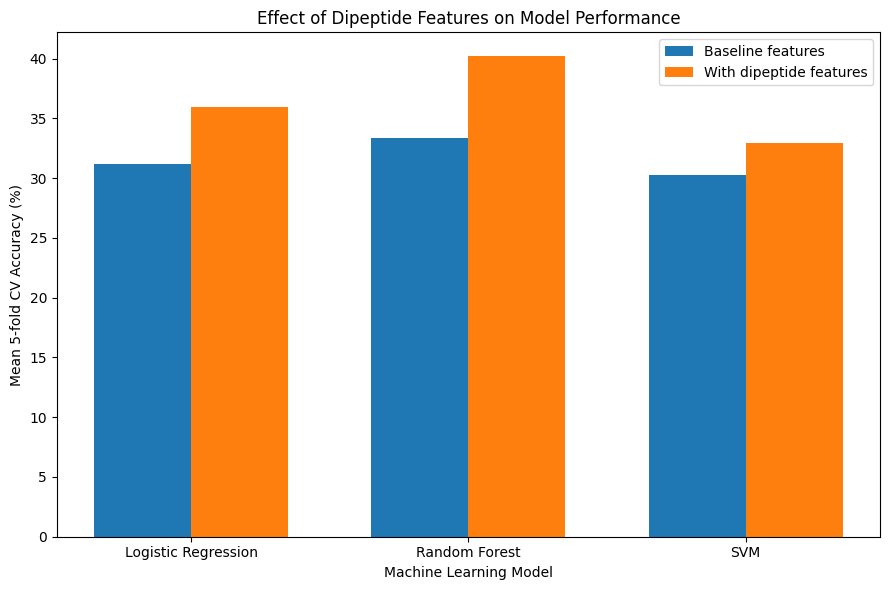

In [48]:
import matplotlib.pyplot as plt
import numpy as np

models = comparison_results["Model"]

baseline = comparison_results["Baseline_Mean_%"]
dipeptide = comparison_results["Dipeptide_Mean_%"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width/2,
    baseline,
    width,
    label="Baseline features"
)

plt.bar(
    x + width/2,
    dipeptide,
    width,
    label="With dipeptide features"
)

plt.xticks(x, models)
plt.ylabel("Mean 5-fold CV Accuracy (%)")
plt.xlabel("Machine Learning Model")
plt.title("Effect of Dipeptide Features on Model Performance")
plt.legend()

plt.tight_layout()

plt.savefig(
    "baseline_vs_dipeptide_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
from sklearn.model_selection import StratifiedKFold

# Create reproducible 5-fold stratified cross-validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print(cv_strategy)

Cross-validation strategy:
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [50]:
# Final 5-fold stratified cross-validation
# The same folds will be used for all models

# ----- Baseline features -----

final_cv_lr = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv_strategy,
    scoring="accuracy"
)

final_cv_rf = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv_strategy,
    scoring="accuracy"
)

final_cv_svm = cross_val_score(
    svm_model,
    X,
    y,
    cv=cv_strategy,
    scoring="accuracy"
)


# ----- Dipeptide features -----

final_cv_lr_dipeptide = cross_val_score(
    logistic_dipeptide,
    X_dipeptide,
    y,
    cv=cv_strategy,
    scoring="accuracy"
)

final_cv_rf_dipeptide = cross_val_score(
    rf_dipeptide,
    X_dipeptide,
    y,
    cv=cv_strategy,
    scoring="accuracy"
)

final_cv_svm_dipeptide = cross_val_score(
    svm_dipeptide,
    X_dipeptide,
    y,
    cv=cv_strategy,
    scoring="accuracy"
)


print("===== FINAL BASELINE CV =====")

print("Logistic Regression:", final_cv_lr)
print("Random Forest:", final_cv_rf)
print("SVM:", final_cv_svm)


print("\n===== FINAL DIPEPTIDE CV =====")

print("Logistic Regression:", final_cv_lr_dipeptide)
print("Random Forest:", final_cv_rf_dipeptide)
print("SVM:", final_cv_svm_dipeptide)

===== FINAL BASELINE CV =====
Logistic Regression: [0.33333333 0.28205128 0.28947368 0.31578947 0.42105263]
Random Forest: [0.30769231 0.33333333 0.44736842 0.42105263 0.5       ]
SVM: [0.30769231 0.41025641 0.34210526 0.31578947 0.44736842]

===== FINAL DIPEPTIDE CV =====
Logistic Regression: [0.33333333 0.41025641 0.42105263 0.28947368 0.47368421]
Random Forest: [0.30769231 0.38461538 0.28947368 0.42105263 0.55263158]
SVM: [0.43589744 0.35897436 0.36842105 0.36842105 0.36842105]


In [51]:
import pandas as pd

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Baseline_Mean_CV": [
        final_cv_lr.mean(),
        final_cv_rf.mean(),
        final_cv_svm.mean()
    ],
    "Baseline_SD": [
        final_cv_lr.std(),
        final_cv_rf.std(),
        final_cv_svm.std()
    ],
    "Dipeptide_Mean_CV": [
        final_cv_lr_dipeptide.mean(),
        final_cv_rf_dipeptide.mean(),
        final_cv_svm_dipeptide.mean()
    ],
    "Dipeptide_SD": [
        final_cv_lr_dipeptide.std(),
        final_cv_rf_dipeptide.std(),
        final_cv_svm_dipeptide.std()
    ]
})

final_comparison["Baseline_Mean_%"] = final_comparison["Baseline_Mean_CV"] * 100
final_comparison["Baseline_SD_%"] = final_comparison["Baseline_SD"] * 100

final_comparison["Dipeptide_Mean_%"] = final_comparison["Dipeptide_Mean_CV"] * 100
final_comparison["Dipeptide_SD_%"] = final_comparison["Dipeptide_SD"] * 100

final_comparison["Change_pp"] = (
    final_comparison["Dipeptide_Mean_%"]
    - final_comparison["Baseline_Mean_%"]
)

print(final_comparison[
    [
        "Model",
        "Baseline_Mean_%",
        "Baseline_SD_%",
        "Dipeptide_Mean_%",
        "Dipeptide_SD_%",
        "Change_pp"
    ]
].round(2))

                 Model  Baseline_Mean_%  Baseline_SD_%  Dipeptide_Mean_%  \
0  Logistic Regression            32.83           4.99             38.56   
1        Random Forest            40.19           7.16             39.11   
2                  SVM            36.46           5.49             38.00   

   Dipeptide_SD_%  Change_pp  
0            6.57       5.72  
1            9.41      -1.08  
2            2.82       1.54  


In [52]:
final_results_table = final_comparison[
    [
        "Model",
        "Baseline_Mean_%",
        "Baseline_SD_%",
        "Dipeptide_Mean_%",
        "Dipeptide_SD_%",
        "Change_pp"
    ]
].copy()

final_results_table.columns = [
    "Model",
    "Baseline_Mean_Percent",
    "Baseline_SD_Percent",
    "Dipeptide_Mean_Percent",
    "Dipeptide_SD_Percent",
    "Change_Percentage_Points"
]

final_results_table = final_results_table.round(2)

final_results_table.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Final results table:")
display(final_results_table)

print("\nSaved as: final_model_comparison.csv")

Final results table:


,Model,Baseline_Mean_Percent,Baseline_SD_Percent,Dipeptide_Mean_Percent,Dipeptide_SD_Percent,Change_Percentage_Points
0,Logistic Regression,32.83,4.99,38.56,6.57,5.72
1,Random Forest,40.19,7.16,39.11,9.41,-1.08
2,SVM,36.46,5.49,38.00,2.82,1.54



Saved as: final_model_comparison.csv


In [53]:
project_summary = {
    "Dataset_Size": len(df),
    "Number_of_Features_Baseline": X.shape[1],
    "Number_of_Features_With_Dipeptides": X_dipeptide.shape[1],
    "Number_of_Function_Classes": y.nunique(),
    "Classes": ", ".join(sorted(y.unique())),
    "Training_Size": len(X_train),
    "Testing_Size": len(X_test)
}

print("===== PROJECT SUMMARY =====")
for key, value in project_summary.items():
    print(f"{key}: {value}")

===== PROJECT SUMMARY =====
Dataset_Size: 192
Number_of_Features_Baseline: 25
Number_of_Features_With_Dipeptides: 425
Number_of_Function_Classes: 4
Classes: Hydrolases, Lyases, Oxidoreductases, Transferases
Training_Size: 153
Testing_Size: 39


In [54]:
final_results = final_results_table.copy()

final_results["Dataset_Size"] = len(df)
final_results["Function_Classes"] = y.nunique()
final_results["Baseline_Features"] = X.shape[1]
final_results["Dipeptide_Features"] = X_dipeptide.shape[1]
final_results["CV_Folds"] = 5

final_results.to_csv(
    "final_project_results.csv",
    index=False
)

print("===== FINAL PROJECT RESULTS =====")
display(final_results)

print("\nSaved as: final_project_results.csv")

===== FINAL PROJECT RESULTS =====


,Model,Baseline_Mean_Percent,Baseline_SD_Percent,Dipeptide_Mean_Percent,Dipeptide_SD_Percent,Change_Percentage_Points,Dataset_Size,Function_Classes,Baseline_Features,Dipeptide_Features,CV_Folds
0,Logistic Regression,32.83,4.99,38.56,6.57,5.72,192,4,25,425,5
1,Random Forest,40.19,7.16,39.11,9.41,-1.08,192,4,25,425,5
2,SVM,36.46,5.49,38.00,2.82,1.54,192,4,25,425,5



Saved as: final_project_results.csv


In [55]:
import os

# Create project folders
folders = [
    "Protein_Function_Prediction",
    "Protein_Function_Prediction/data",
    "Protein_Function_Prediction/results",
    "Protein_Function_Prediction/figures"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("GitHub project folders created successfully:")
print("✓ Protein_Function_Prediction/")
print("✓ data/")
print("✓ results/")
print("✓ figures/")

GitHub project folders created successfully:
✓ Protein_Function_Prediction/
✓ data/
✓ results/
✓ figures/


In [56]:
import shutil
import os

# Copy result files
result_files = [
    "final_project_results.csv",
    "final_model_comparison.csv",
    "feature_importance.csv"
]

for file in result_files:
    if os.path.exists(file):
        shutil.copy(
            file,
            f"Protein_Function_Prediction/results/{file}"
        )

# Copy figure files
figure_files = [
    "baseline_vs_dipeptide_accuracy.png",
    "model_accuracy_comparison.png",
    "top_10_feature_importance.png",
    "logistic_regression_confusion_matrix.png",
    "random_forest_confusion_matrix.png",
    "svm_confusion_matrix.png"
]

for file in figure_files:
    if os.path.exists(file):
        shutil.copy(
            file,
            f"Protein_Function_Prediction/figures/{file}"
        )

print("===== GITHUB FILE ORGANIZATION =====")

print("\nResults:")
for file in result_files:
    path = f"Protein_Function_Prediction/results/{file}"
    if os.path.exists(path):
        print("✓", file)

print("\nFigures:")
for file in figure_files:
    path = f"Protein_Function_Prediction/figures/{file}"
    if os.path.exists(path):
        print("✓", file)

===== GITHUB FILE ORGANIZATION =====

Results:
✓ final_project_results.csv
✓ final_model_comparison.csv
✓ feature_importance.csv

Figures:
✓ baseline_vs_dipeptide_accuracy.png
✓ model_accuracy_comparison.png
✓ top_10_feature_importance.png
✓ logistic_regression_confusion_matrix.png
✓ random_forest_confusion_matrix.png
✓ svm_confusion_matrix.png


In [57]:
dataset_info = """# Dataset Information

## Data Source

Protein sequences were obtained from the UniProtKB/Swiss-Prot reviewed protein database using the UniProt REST API.

## Dataset Construction

The dataset was constructed using reviewed protein entries belonging to four top-level Enzyme Commission (EC) functional classes:

- EC1: Oxidoreductases
- EC2: Transferases
- EC3: Hydrolases
- EC4: Lyases

Proteins were restricted to sequences with lengths between 100 and 500 amino acids.

## Final Dataset

After quality control and removal of duplicate entries and one sequence containing the non-standard amino acid residue U (selenocysteine), the final dataset contained:

- 192 protein sequences
- 4 functional classes

### Class Distribution

| Functional Class | Number of Proteins |
|---|---:|
| Oxidoreductases | 49 |
| Lyases | 49 |
| Transferases | 47 |
| Hydrolases | 47 |

## Feature Representation

Two feature representations were evaluated.

### Baseline Features

The baseline representation contained:

- 20 amino-acid composition features
- 5 physicochemical properties

Total: **25 features**

### Dipeptide Representation

The second representation additionally included:

- 400 possible dipeptide composition features

Total: **425 features**

## Data Quality Control

The following checks were performed:

1. Missing-value inspection
2. Duplicate protein-entry inspection
3. Duplicate sequence inspection
4. Amino-acid sequence validation
5. Removal of one sequence containing U (selenocysteine)

## Important Scope

This project represents a simplified four-class enzyme functional classification problem. It is not intended to represent the complete multi-label protein-function prediction problem involving Gene Ontology annotations.

The dataset is relatively small and the resulting models should therefore be interpreted as a computational proof-of-concept.
"""

with open(
    "Protein_Function_Prediction/data/dataset_information.md",
    "w"
) as f:
    f.write(dataset_info)

print("Created successfully:")
print("✓ Protein_Function_Prediction/data/dataset_information.md")

Created successfully:
✓ Protein_Function_Prediction/data/dataset_information.md


In [58]:
requirements = """pandas
numpy
biopython
scikit-learn
matplotlib
seaborn
requests
"""

with open(
    "Protein_Function_Prediction/requirements.txt",
    "w"
) as f:
    f.write(requirements)

print("Created successfully:")
print("✓ Protein_Function_Prediction/requirements.txt")

print("\nContents:")
print(requirements)

Created successfully:
✓ Protein_Function_Prediction/requirements.txt

Contents:
pandas
numpy
biopython
scikit-learn
matplotlib
seaborn
requests



In [59]:
readme = """# Machine Learning-Based Enzyme Function Classification from Protein Sequences

## Overview

This project investigates whether machine-learning models can classify proteins into broad enzyme functional classes using features derived directly from their amino-acid sequences.

The study compares conventional sequence-composition and physicochemical features with additional dipeptide composition features using three machine-learning approaches:

- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

The project was designed as a reproducible computational proof-of-concept for sequence-based enzyme function classification.

---

## Research Question

**Can machine-learning models predict the functional class of a protein using features derived from its amino-acid sequence?**

---

## Dataset

Protein sequences were obtained from the **UniProtKB/Swiss-Prot reviewed protein database** using the UniProt REST API.

Four top-level Enzyme Commission (EC) classes were studied:

| EC Class | Functional Class | Proteins |
|---|---|---:|
| EC1 | Oxidoreductases | 49 |
| EC2 | Transferases | 47 |
| EC3 | Hydrolases | 47 |
| EC4 | Lyases | 49 |
| **Total** | | **192** |

Protein sequences were restricted to lengths between 100 and 500 amino acids.

Detailed dataset information is available in:

`data/dataset_information.md`

---

## Computational Workflow

```text
UniProtKB/Swiss-Prot
        |
        v
Protein sequence collection
        |
        v
Quality control
        |
        v
Amino-acid composition
        +
Physicochemical features
        |
        v
Baseline feature set
(25 features)
        |
        +----------------------+
        |                      |
        v                      v
Machine Learning       Add dipeptide features
                        (400 additional features)
        |                      |
        v                      v
Logistic Regression    Logistic Regression
Random Forest          Random Forest
SVM                    SVM
        |                      |
        +----------+-----------+
                   |
                   v
          Cross-validation
                   |
                   v
        Performance comparison

_IncompleteInputError: incomplete input (1181115993.py, line 1)

In [60]:
readme = """# Machine Learning-Based Enzyme Function Classification from Protein Sequences

## Overview

This project investigates whether machine-learning models can classify proteins into broad enzyme functional classes using features derived from their amino-acid sequences.

The study compares conventional sequence-composition and physicochemical features with additional dipeptide composition features using three machine-learning approaches:

- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

The project was designed as a reproducible computational proof-of-concept for sequence-based enzyme function classification.

## Research Question

Can machine-learning models predict the functional class of a protein using features derived from its amino-acid sequence?

## Dataset

Protein sequences were obtained from the UniProtKB/Swiss-Prot reviewed protein database using the UniProt REST API.

Four top-level Enzyme Commission (EC) classes were studied:

| EC Class | Functional Class | Proteins |
|---|---|---:|
| EC1 | Oxidoreductases | 49 |
| EC2 | Transferases | 47 |
| EC3 | Hydrolases | 47 |
| EC4 | Lyases | 49 |
| Total | | 192 |

Protein sequences were restricted to lengths between 100 and 500 amino acids.

Detailed dataset information is available in:

data/dataset_information.md

## Computational Workflow

UniProtKB/Swiss-Prot
→ Protein sequence collection
→ Quality control
→ Feature extraction
→ Machine learning
→ 5-fold cross-validation
→ Performance comparison
→ Biological interpretation

## Feature Engineering

### Baseline Features

The baseline representation contained:

- 20 amino-acid composition features
- Molecular weight
- Aromaticity
- Instability index
- Isoelectric point
- GRAVY

Total: 25 features.

### Dipeptide Features

The second representation additionally included all 400 possible dipeptide composition features.

Total:

25 baseline features + 400 dipeptide features = 425 features.

## Machine Learning Models

Three classification algorithms were evaluated:

1. Logistic Regression
2. Random Forest
3. Support Vector Machine with an RBF kernel

## Evaluation Strategy

The final evaluation used stratified 5-fold cross-validation with shuffling and random state 42.

Performance is reported as mean accuracy ± standard deviation across the five folds.

## Final Results

| Model | Baseline Features | With Dipeptides | Change |
|---|---:|---:|---:|
| Logistic Regression | 32.83 ± 4.99% | 38.56 ± 6.57% | +5.72 pp |
| Random Forest | 40.19 ± 7.16% | 39.11 ± 9.41% | -1.08 pp |
| SVM | 36.46 ± 5.49% | 38.00 ± 2.82% | +1.54 pp |

pp = percentage points.

### Main Observation

The effect of adding dipeptide features was model-dependent.

Logistic Regression and SVM showed improved mean cross-validated accuracy after adding dipeptide features, whereas Random Forest showed a small decrease.

This indicates that additional sequence-order information does not necessarily improve every machine-learning model under the same dataset and experimental conditions.

## Results and Figures

The repository contains:

- Baseline vs. dipeptide accuracy comparison
- Model accuracy comparison
- Top 10 Random Forest feature importances
- Logistic Regression confusion matrix
- Random Forest confusion matrix
- SVM confusion matrix

## Feature Importance

Random Forest feature importance was examined to identify features that contributed most strongly to model predictions.

Feature importance should be interpreted as model-specific predictive contribution, not as evidence that an individual amino acid or physicochemical property biologically determines enzyme function.

## Project Structure

Protein_Function_Prediction/
├── Protein_Function_Prediction.ipynb
├── README.md
├── requirements.txt
├── data/
│   └── dataset_information.md
├── results/
│   ├── final_project_results.csv
│   ├── final_model_comparison.csv
│   └── feature_importance.csv
└── figures/
    ├── baseline_vs_dipeptide_accuracy.png
    ├── model_accuracy_comparison.png
    ├── top_10_feature_importance.png
    ├── logistic_regression_confusion_matrix.png
    ├── random_forest_confusion_matrix.png
    └── svm_confusion_matrix.png

## Reproducibility

The project was implemented in Python using:

- Python
- Pandas
- NumPy
- Biopython
- Scikit-learn
- Matplotlib
- Seaborn
- Requests

Required packages are listed in requirements.txt.

## Limitations

This study is a small computational proof-of-concept.

Key limitations include:

1. The dataset contains only 192 protein sequences.
2. Only four broad enzyme functional classes were considered.
3. Protein function is more complex than the four-class classification problem used here.
4. The feature space becomes high-dimensional when dipeptide features are included.
5. The current evaluation does not explicitly control for protein sequence homology between training and testing folds.
6. Accuracy alone does not capture every aspect of multiclass classification performance.
7. The results should not be interpreted as a general solution to protein function prediction.

## Future Extensions

Possible extensions include:

- Larger protein datasets
- Homology-aware train/test splitting
- More refined enzyme subclasses
- Gene Ontology-based functional annotation
- Additional sequence representations
- Protein embeddings from pretrained protein language models
- More comprehensive evaluation metrics
- Independent external validation

## Conclusion

This project demonstrates a reproducible machine-learning workflow for classifying enzyme functional classes from protein sequence-derived features.

The comparison between baseline sequence features and dipeptide-enriched representations demonstrates that feature representation can influence model performance differently across machine-learning algorithms.

The work provides a foundation for developing more sophisticated protein-function prediction systems using larger datasets, homology-aware evaluation, and modern protein representation learning.

## Author

Ishita Singh

B.Tech Bioinformatics
Isabella Thoburn College of Professional Studies
AKTU

## License

This project is intended for academic and educational research purposes.
"""

with open(
    "Protein_Function_Prediction/README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

print("========================================")
print("FINAL STEP COMPLETED")
print("========================================")
print("✓ README.md created")
print("✓ Dataset documentation created")
print("✓ Requirements file created")
print("✓ Results organized")
print("✓ Figures organized")
print("✓ Project documentation completed")
print("\nYour project is ready for GitHub.")

FINAL STEP COMPLETED
✓ README.md created
✓ Dataset documentation created
✓ Requirements file created
✓ Results organized
✓ Figures organized
✓ Project documentation completed

Your project is ready for GitHub.


In [61]:
import shutil

shutil.make_archive(
    "Protein_Function_Prediction",
    "zip",
    "Protein_Function_Prediction"
)

print("Created: Protein_Function_Prediction.zip")

Created: Protein_Function_Prediction.zip
